## 1. Import Libraries

In [7]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import time
import deepxde as dde

# Use PyTorch backend for deepxde
dde.backend.set_default_backend('pytorch')

# Enable faster CUDA behavior when available
torch.backends.cudnn.benchmark = True
warnings.filterwarnings('ignore')

Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


## 2. Load Training and Test Data

In [8]:
# Load datasets
data_dir = Path('/home/curry/Documents/NO4Jean/datasets')

train_data = np.load(data_dir / 'train_data_30_04.npz')
test_data = np.load(data_dir / 'test_data_30_04.npz')

X_train = train_data['X'].astype(np.float32)  # (1600, 20)
Y_train = train_data['Y'].astype(np.float32)  # (1600, 200)
X_test = test_data['X'].astype(np.float32)    # (400, 20)
Y_test = test_data['Y'].astype(np.float32)    # (400, 200)

print('Dataset loaded:')
print(f'  X_train: {X_train.shape}')
print(f'  Y_train: {Y_train.shape}')
print(f'  X_test: {X_test.shape}')
print(f'  Y_test: {Y_test.shape}')

# Data statistics
print(f'\nX_train: mean={X_train.mean():.6f}, std={X_train.std():.6f}')
print(f'Y_train: mean={Y_train.mean():.6f}, std={Y_train.std():.6f}')
print(f'X_test: mean={X_test.mean():.6f}, std={X_test.std():.6f}')
print(f'Y_test: mean={Y_test.mean():.6f}, std={Y_test.std():.6f}')

Dataset loaded:
  X_train: (1600, 20)
  Y_train: (1600, 200)
  X_test: (400, 20)
  Y_test: (400, 200)

X_train: mean=0.259565, std=1.083137
Y_train: mean=-0.060979, std=2.166297
X_test: mean=0.262510, std=1.077588
Y_test: mean=-0.063941, std=1.421018


## 3. Data Standardization

The training and test sets are standardized before model fitting. The raw distribution is kept only for diagnosis, but the model trains on z-scored inputs and targets.

In [9]:
# Standardize data before training
print('='*70)
print('STEP 1: Data Standardization')
print('='*70)

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True)
Y_mean = Y_train.mean(axis=0, keepdims=True)
Y_std = Y_train.std(axis=0, keepdims=True)

X_std = np.where(X_std < 1e-8, 1.0, X_std)
Y_std = np.where(Y_std < 1e-8, 1.0, Y_std)

X_train_norm = (X_train - X_mean) / X_std
Y_train_norm = (Y_train - Y_mean) / Y_std
X_test_norm = (X_test - X_mean) / X_std
Y_test_norm = (Y_test - Y_mean) / Y_std

print(f'X_train_norm: mean={X_train_norm.mean():.6f}, std={X_train_norm.std():.6f}')
print(f'Y_train_norm: mean={Y_train_norm.mean():.6f}, std={Y_train_norm.std():.6f}')
print(f'X_test_norm:  mean={X_test_norm.mean():.6f}, std={X_test_norm.std():.6f}')
print(f'Y_test_norm:  mean={Y_test_norm.mean():.6f}, std={Y_test_norm.std():.6f}')

print('\nNormalization parameters saved for later inverse transform.')
print('='*70)

STEP 1: Data Standardization
X_train_norm: mean=-0.000000, std=1.000000
Y_train_norm: mean=0.000000, std=1.000000
X_test_norm:  mean=-0.005927, std=1.005696
Y_test_norm:  mean=0.003020, std=0.849755

Normalization parameters saved for later inverse transform.


## 4. Define DeepONet Architecture

In [10]:
# Network dimensions for DeepONet

dim_x = 1                  # trunk input: coordinate dimension
num_outputs = 200          # directly predict 200-dim output vector
m = 20                     # branch input dimension
p = 128                    # latent width for branch/trunk
activation = 'relu'
kernel = 'Glorot normal'

# Branch/trunk MLPs
branch_layers = [m, 128, 128, 128, p]
trunk_layers = [dim_x, 64, 64, p]

# Initialize DeepONet
if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available, but GPU training was requested.')

device = torch.device('cuda')
model_no = dde.nn.DeepONet(branch_layers, trunk_layers, activation, kernel).to(device)

# Prepare trunk coordinates for all output points
trunk_coords_np = np.linspace(0, 1, num_outputs).reshape(-1, 1).astype(np.float32)
trunk_coords = torch.from_numpy(trunk_coords_np).to(device)

# Batch inference helper: output shape (B, 200)
def deeponet_batch_inference(model, branch_batch, trunk_coords):
    B = branch_batch.shape[0]
    N = trunk_coords.shape[0]

    outputs = []
    for i in range(B):
        branch_single = branch_batch[i:i+1]
        branch_repeated = branch_single.repeat(N, 1)
        output = model((branch_repeated, trunk_coords))
        if output.dim() > 1:
            output = output.squeeze(-1)
        outputs.append(output)

    return torch.stack(outputs, dim=0)

# Count parameters
total_params = sum(param.numel() for param in model_no.parameters())
print(f'Device: {device}')
print('DeepONet Architecture:')
print(f'  Branch net: {m} -> 128 -> 128 -> 128 -> {p}')
print(f'  Trunk net:  {dim_x} -> 64 -> 64 -> {p}')
print(f'  Output: direct vector with {num_outputs} points (no interpolation)')
print(f'Total parameters: {total_params:,}')

Device: cuda
DeepONet Architecture:
  Branch net: 20 -> 128 -> 128 -> 128 -> 128
  Trunk net:  1 -> 64 -> 64 -> 128
  Output: direct vector with 200 points (no interpolation)
Total parameters: 64,833


## 5. Prepare Standardized Tensors

In [11]:
# Convert standardized arrays to tensors
X_train_norm_tensor = torch.from_numpy(X_train_norm).float()
Y_train_norm_tensor = torch.from_numpy(Y_train_norm).float()
X_test_norm_tensor = torch.from_numpy(X_test_norm).float()
Y_test_norm_tensor = torch.from_numpy(Y_test_norm).float()

batch_size = 32
num_train = X_train_norm_tensor.shape[0]
num_test = X_test_norm_tensor.shape[0]

print('Standardized Tensor Configuration:')
print(f'  Batch size: {batch_size}')
print(f'  Training samples: {num_train}')
print(f'  Test samples: {num_test}')
print(f'  Batches per epoch: {int(np.ceil(num_train / batch_size))}')
print('  Using manual batching on standardized data')

Standardized Tensor Configuration:
  Batch size: 32
  Training samples: 1600
  Test samples: 400
  Batches per epoch: 50
  Using manual batching on standardized data


## 6. Training Configuration and Loop

In [12]:
# Training hyperparameters
num_epochs = 800
learning_rate = 0.001
step_size = 200
gamma_scheduler = 0.7

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_no.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma_scheduler)

print('Training Configuration:')
print(f'  Epochs: {num_epochs}')
print(f'  Learning rate: {learning_rate}')
print(f'  Batch size: {batch_size}')
print(f'  Data scale: standardized')
print('  Loss: MSELoss')
print('  Optimizer: Adam')
print(f'  LR Scheduler: StepLR (step_size={step_size}, gamma={gamma_scheduler})')
print(f'  Device: {device}')

train_loss_history = []
test_loss_history = []
best_test_loss = float('inf')
model_save_path = '/home/curry/Documents/NO4Jean/neural_operator_model_standardized.pt'

print(f'\n{"="*70}')
print('Starting Training...')
print(f'{"="*70}\n')

for epoch in range(num_epochs):
    model_no.train()
    train_loss = 0.0
    epoch_start = time.time()

    # Keep indices on CPU because X_train_norm_tensor / Y_train_norm_tensor are on CPU
    perm = torch.randperm(num_train, device='cpu')
    for start in range(0, num_train, batch_size):
        idx = perm[start:start + batch_size]
        batch_x = X_train_norm_tensor[idx].to(device, non_blocking=True)
        batch_y = Y_train_norm_tensor[idx].to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = deeponet_batch_inference(model_no, batch_x, trunk_coords)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= int(np.ceil(num_train / batch_size))
    train_loss_history.append(train_loss)

    model_no.eval()
    test_loss = 0.0
    with torch.no_grad():
        for start in range(0, num_test, batch_size):
            batch_x = X_test_norm_tensor[start:start + batch_size].to(device, non_blocking=True)
            batch_y = Y_test_norm_tensor[start:start + batch_size].to(device, non_blocking=True)
            outputs = deeponet_batch_inference(model_no, batch_x, trunk_coords)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()

    test_loss /= int(np.ceil(num_test / batch_size))
    test_loss_history.append(test_loss)

    scheduler.step()
    epoch_time = time.time() - epoch_start

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model_no.state_dict(), model_save_path)

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:4d}/{num_epochs} | Train Loss: {train_loss:.8f} | Test Loss: {test_loss:.8f} | Time: {epoch_time:.2f}s')

print(f'\n{"="*70}')
print('Training Complete!')
print(f'Best test loss: {best_test_loss:.8f}')
print(f'Model saved to: {model_save_path}')
print(f'{"="*70}')

Training Configuration:
  Epochs: 800
  Learning rate: 0.001
  Batch size: 32
  Data scale: standardized
  Loss: MSELoss
  Optimizer: Adam
  LR Scheduler: StepLR (step_size=200, gamma=0.7)
  Device: cuda

Starting Training...

Epoch    1/800 | Train Loss: 0.98445172 | Test Loss: 0.67056507 | Time: 1.21s
Epoch  100/800 | Train Loss: 0.78088679 | Test Loss: 0.61491336 | Time: 1.07s
Epoch  200/800 | Train Loss: 0.77702190 | Test Loss: 0.60480001 | Time: 1.01s
Epoch  300/800 | Train Loss: 0.75348418 | Test Loss: 0.60404425 | Time: 1.04s
Epoch  400/800 | Train Loss: 0.75181725 | Test Loss: 0.60599506 | Time: 1.06s
Epoch  500/800 | Train Loss: 0.74292429 | Test Loss: 0.60174852 | Time: 1.04s
Epoch  600/800 | Train Loss: 0.74037820 | Test Loss: 0.60480790 | Time: 1.03s
Epoch  700/800 | Train Loss: 0.73734504 | Test Loss: 0.60092840 | Time: 1.06s
Epoch  800/800 | Train Loss: 0.73778187 | Test Loss: 0.60279294 | Time: 1.06s

Training Complete!
Best test loss: 0.59677752
Model saved to: /home/cu

## 7. Load Best Model and Visualize Training History

Loaded best model from /home/curry/Documents/NO4Jean/neural_operator_model_standardized.pt


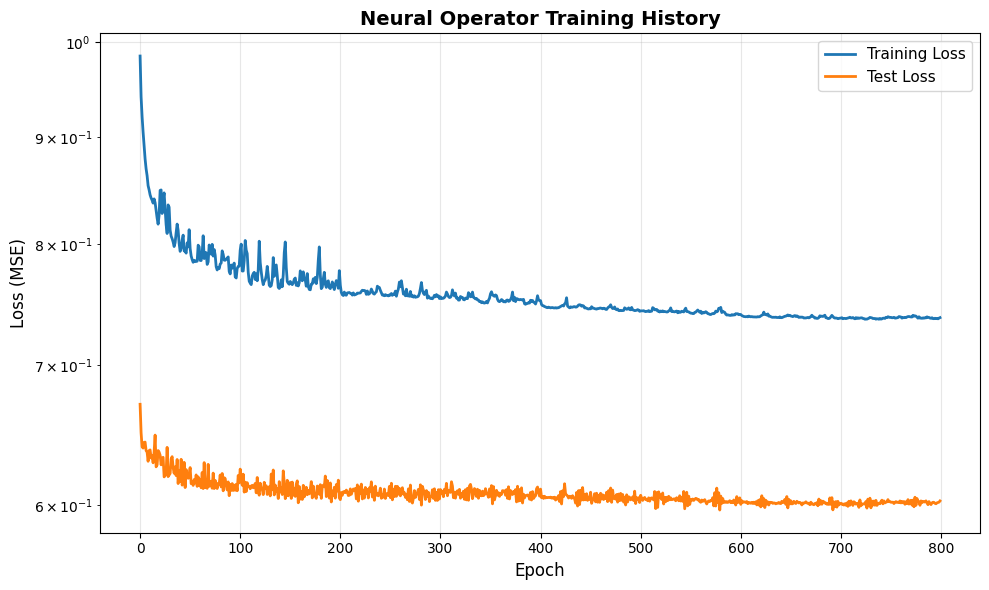


Training History:
  Final train loss: 0.73778187
  Final test loss: 0.60279294
  Best test loss: 0.59677752


In [13]:
# Load best model
model_no.load_state_dict(torch.load(model_save_path, map_location=device))
model_no.eval()
print(f'Loaded best model from {model_save_path}')

# Plot training history
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(train_loss_history, label='Training Loss', linewidth=2)
ax.semilogy(test_loss_history, label='Test Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Neural Operator Training History', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/curry/Documents/NO4Jean/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTraining History:')
print(f'  Final train loss: {train_loss_history[-1]:.8f}')
print(f'  Final test loss: {test_loss_history[-1]:.8f}')
print(f'  Best test loss: {best_test_loss:.8f}')

## 8. Validation and Output Reconstruction

In [14]:
# Predictions on standardized test set
model_no.eval()
with torch.no_grad():
    X_test_gpu = X_test_norm_tensor.to(device)
    Y_pred_norm_tensor = deeponet_batch_inference(model_no, X_test_gpu, trunk_coords)
    Y_pred_norm = Y_pred_norm_tensor.detach().cpu().numpy()

# Inverse transform to original scale
Y_pred = Y_pred_norm * Y_std + Y_mean

# Metrics on both scales
mse_norm = np.mean((Y_pred_norm - Y_test_norm) ** 2)
mae_norm = np.mean(np.abs(Y_pred_norm - Y_test_norm))
mse = np.mean((Y_pred - Y_test) ** 2)
mae = np.mean(np.abs(Y_pred - Y_test))
rmse = np.sqrt(mse)

print('Test Set Metrics:')
print(f'  Normalized MSE: {mse_norm:.8f}')
print(f'  Normalized MAE: {mae_norm:.8f}')
print(f'  Raw MSE: {mse:.8f}')
print(f'  Raw MAE: {mae:.8f}')
print(f'  Raw RMSE: {rmse:.8f}')

# Reshape outputs back to original shape (25, 2, 2)
print('\nReconstructing kernel shapes...')
K_con_pred = Y_pred[:, :100].reshape(-1, 25, 2, 2)
L_con_pred = Y_pred[:, 100:].reshape(-1, 25, 2, 2)
K_con_true = Y_test[:, :100].reshape(-1, 25, 2, 2)
L_con_true = Y_test[:, 100:].reshape(-1, 25, 2, 2)

print(f'  K_con predicted shape: {K_con_pred.shape}')
print(f'  K_con ground truth shape: {K_con_true.shape}')
print(f'  L_con predicted shape: {L_con_pred.shape}')
print(f'  L_con ground truth shape: {L_con_true.shape}')

K_con_mse = np.mean((K_con_pred - K_con_true) ** 2)
L_con_mse = np.mean((L_con_pred - L_con_true) ** 2)
print('\nPer-Kernel Errors (raw scale):')
print(f'  K_con MSE: {K_con_mse:.8f}')
print(f'  L_con MSE: {L_con_mse:.8f}')

Test Set Metrics:
  Normalized MSE: 0.60138893
  Normalized MAE: 0.50905746
  Raw MSE: 2.02963114
  Raw MAE: 0.73568714
  Raw RMSE: 1.42465127

Reconstructing kernel shapes...
  K_con predicted shape: (400, 25, 2, 2)
  K_con ground truth shape: (400, 25, 2, 2)
  L_con predicted shape: (400, 25, 2, 2)
  L_con ground truth shape: (400, 25, 2, 2)

Per-Kernel Errors (raw scale):
  K_con MSE: 0.64082915
  L_con MSE: 3.41843271


In [15]:
# === Detailed Loss Analysis ===
print("="*70)
print("DETAILED LOSS ANALYSIS")
print("="*70)

# 1. Absolute error metrics
abs_error = np.abs(Y_pred - Y_test)
print("\n1. Absolute Error Metrics:")
print(f"   Mean absolute error (MAE): {abs_error.mean():.6f}")
print(f"   Median absolute error: {np.median(abs_error):.6f}")
print(f"   Std of absolute error: {abs_error.std():.6f}")
print(f"   Max absolute error: {abs_error.max():.6f}")

# 2. Relative error metrics (MAPE)
# Avoid division by zero
mask = np.abs(Y_test) > 1e-6
relative_error = np.abs(Y_pred[mask] - Y_test[mask]) / (np.abs(Y_test[mask]) + 1e-8)
mape = 100 * relative_error.mean()
print(f"\n2. Relative Error Metrics:")
print(f"   MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"   Median APE: {100 * np.median(relative_error):.2f}%")

# 3. Per-sample errors (L2 norm)
pred_l2 = np.linalg.norm(Y_pred, axis=1)
true_l2 = np.linalg.norm(Y_test, axis=1)
l2_error = np.linalg.norm(Y_pred - Y_test, axis=1)
rel_l2_error = l2_error / (true_l2 + 1e-8)

print(f"\n3. Per-Sample L2 Norm Errors:")
print(f"   Mean L2 error: {l2_error.mean():.4f}")
print(f"   Median L2 error: {np.median(l2_error):.4f}")
print(f"   Mean relative L2 error: {rel_l2_error.mean():.4f} ({100*rel_l2_error.mean():.2f}%)")
print(f"   Median relative L2 error: {np.median(rel_l2_error):.4f} ({100*np.median(rel_l2_error):.2f}%)")

# 4. Data scale analysis
print(f"\n4. Data Scale Analysis:")
print(f"   Y_test L2 norms: min={true_l2.min():.2f}, mean={true_l2.mean():.2f}, max={true_l2.max():.2f}")
print(f"   Y_pred L2 norms: min={pred_l2.min():.2f}, mean={pred_l2.mean():.2f}, max={pred_l2.max():.2f}")

# 5. MSE in context
print(f"\n5. MSE in Context:")
print(f"   MSE: {mse:.6f}")
print(f"   RMSE: {rmse:.6f}")
print(f"   Y_test variance: {Y_test.var():.6f}")
print(f"   Normalized MSE (MSE / Var(Y)): {mse / Y_test.var():.6f}")
print(f"   → This means MSE is {100 * mse / Y_test.var():.2f}% of the output variance")

print("="*70)


DETAILED LOSS ANALYSIS

1. Absolute Error Metrics:
   Mean absolute error (MAE): 0.735687
   Median absolute error: 0.395642
   Std of absolute error: 1.219998
   Max absolute error: 58.856464

2. Relative Error Metrics:
   MAPE (Mean Absolute Percentage Error): 540.54%
   Median APE: 97.82%

3. Per-Sample L2 Norm Errors:
   Mean L2 error: 16.0883
   Median L2 error: 12.6107
   Mean relative L2 error: 1.0625 (106.25%)
   Median relative L2 error: 1.0213 (102.13%)

4. Data Scale Analysis:
   Y_test L2 norms: min=2.42, mean=15.69, max=144.16
   Y_pred L2 norms: min=1.76, mean=8.16, max=49.11

5. MSE in Context:
   MSE: 2.029631
   RMSE: 1.424651
   Y_test variance: 2.019293
   Normalized MSE (MSE / Var(Y)): 1.005120
   → This means MSE is 100.51% of the output variance


## 9. Loss Analysis and Error Diagnostics

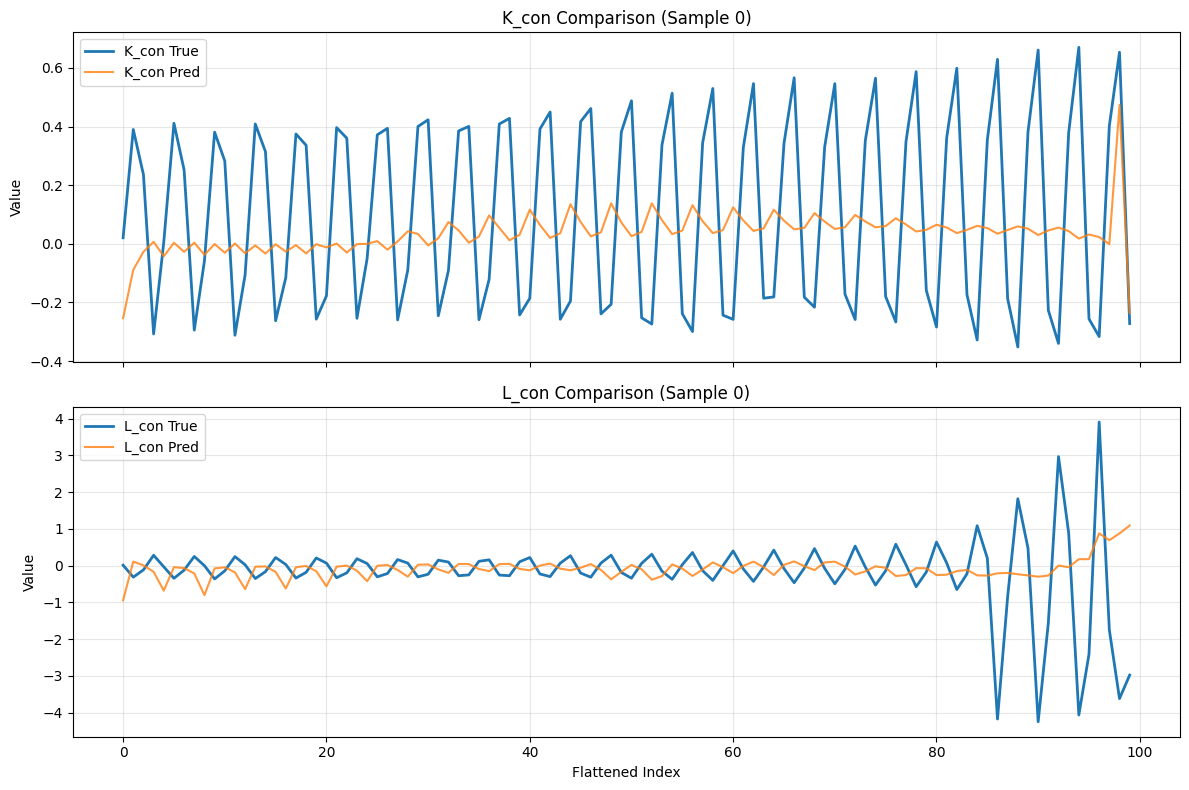

In [16]:
# Visualize sample predictions on raw scale
sample_idx = 0
k_pred_vec = K_con_pred[sample_idx].reshape(-1)
k_true_vec = K_con_true[sample_idx].reshape(-1)
l_pred_vec = L_con_pred[sample_idx].reshape(-1)
l_true_vec = L_con_true[sample_idx].reshape(-1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(k_true_vec, label='K_con True', linewidth=2)
axes[0].plot(k_pred_vec, label='K_con Pred', linewidth=1.5, alpha=0.8)
axes[0].set_title(f'K_con Comparison (Sample {sample_idx})')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(l_true_vec, label='L_con True', linewidth=2)
axes[1].plot(l_pred_vec, label='L_con Pred', linewidth=1.5, alpha=0.8)
axes[1].set_title(f'L_con Comparison (Sample {sample_idx})')
axes[1].set_xlabel('Flattened Index')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/curry/Documents/NO4Jean/prediction_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Predictions and Reconstructed Kernels

In [17]:
# Save all predictions and metrics
results = {
    'Y_pred': Y_pred,
    'Y_pred_norm': Y_pred_norm,
    'Y_test_raw': Y_test,
    'Y_test_norm': Y_test_norm,
    'K_con_pred': K_con_pred,
    'K_con_true': K_con_true,
    'L_con_pred': L_con_pred,
    'L_con_true': L_con_true,
    'train_loss_history': np.array(train_loss_history),
    'test_loss_history': np.array(test_loss_history),
    'mse_norm': mse_norm,
    'mae_norm': mae_norm,
    'mse': mse,
    'mae': mae,
    'rmse': rmse,
    'K_con_mse': K_con_mse,
    'L_con_mse': L_con_mse,
    'X_mean': X_mean,
    'X_std': X_std,
    'Y_mean': Y_mean,
    'Y_std': Y_std
}

save_path = '/home/curry/Documents/NO4Jean/neural_operator_predictions_standardized.npz'
np.savez(save_path, **results)
print(f'Predictions and results saved to: {save_path}')

print(f'\n{"="*70}')
print('Neural Operator Training Complete!')
print(f'{"="*70}')
print(f'Model saved: {model_save_path}')
print(f'Predictions saved: {save_path}')
print(f'\nOutput shapes (reshaped to original):')
print(f'  K_con: {K_con_pred.shape}')
print(f'  L_con: {L_con_pred.shape}')
print(f'\nTest metrics (raw scale):')
print(f'  Raw MSE: {mse:.8f}')
print(f'  K_con MSE: {K_con_mse:.8f}')
print(f'  L_con MSE: {L_con_mse:.8f}')

Predictions and results saved to: /home/curry/Documents/NO4Jean/neural_operator_predictions_standardized.npz

Neural Operator Training Complete!
Model saved: /home/curry/Documents/NO4Jean/neural_operator_model_standardized.pt
Predictions saved: /home/curry/Documents/NO4Jean/neural_operator_predictions_standardized.npz

Output shapes (reshaped to original):
  K_con: (400, 25, 2, 2)
  L_con: (400, 25, 2, 2)

Test metrics (raw scale):
  Raw MSE: 2.02963114
  K_con MSE: 0.64082915
  L_con MSE: 3.41843271
